# Runtime Detection — Inference, SHAP & Drift Tuning
### APT Threat Hunting Platform · FYP experimentation log

**Author:** Niel · **Module:** CSDFE Year 4 · **Notebook 2 of 2**

This notebook is my working journal for the **runtime detection workflow** documented in
`detection-workflow.md`. It loads the candidate models trained in
`01_training_experimentation.ipynb` and reproduces the inference-side experiments:

1. **Batched XGBoost inference** + the **feature-schema pin** (Steps 7 & 10) — how a 55-feature
   DNS model safely selects its columns out of the full 156-feature vector.
2. **SHAP explainability** via `pred_contribs=True` (Step 8) — the top-5 contributing features
   shown on the dashboard alert card.
3. **Threshold comparison + severity laddering** (Steps 7 & 9) — tuning the operating point and
   its effect on alert volume.
4. **Drift monitoring** (Step 9) — driving the real `DriftMonitor` through a distribution shift
   and watching PSI / confidence-shift / detection-rate signals fire.

> Runs **offline** — no Wazuh/Docker stack. All inference uses the *same* helper functions as
> `detection/detectors/_base.py` (`_score_severity`, `_shap_top_k`) and the real
> `detection/drift_monitor.py::DriftMonitor`, so behaviour matches production.


## 0 · Setup & load the trained candidates from Notebook 1

In [1]:
import os, sys, json, time
# Pin every native thread-pool to 1. This environment's OpenMP/BLAS stack is
# flaky when xgboost + numpy + matplotlib share a process; single-threading
# keeps it stable. (The platform itself runs with OMP_NUM_THREADS=1 too.)
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "1")

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)

import numpy as np
import pandas as pd
import xgboost as xgb
from pathlib import Path
# NB: matplotlib is imported LATER (Section 3), right before the first plot —
# importing pyplot ahead of the heavy synthetic data generation intermittently
# segfaults the OpenMP runtime in this sandbox.

ART = Path("notebooks/artifacts")
assert (ART / "dns_exfiltration.json").exists(), \
    "Run 01_training_experimentation.ipynb first — it saves the models into notebooks/artifacts/"

# NOTE: we deliberately load the boosters LATER (Section 2), AFTER synthetic data
# generation + feature extraction. Calling xgb.Booster().load_model() early can
# corrupt the OpenMP heap in this sandbox and segfault the pure-Python generator.
schema = json.loads((ART / "model_schema.json").read_text())
print("schema for:", list(schema))
print("DNS model     :", len(schema['dns_exfiltration']['feature_names']), "features",
      "| grouping", schema['dns_exfiltration']['grouping'])
print("lateral model :", len(schema['lateral_movement']['feature_names']), "features",
      "| grouping", schema['lateral_movement']['grouping'])

schema for: ['dns_exfiltration', 'lateral_movement']
DNS model     : 55 features | grouping hostname
lateral model : 114 features | grouping hostname_user


## 1 · Build a fresh inference window set

At runtime the platform feeds **5-minute window snapshots** through the *same* `FeaturePipeline`
used at training (train/serve parity). I regenerate a small synthetic stream with a **different
seed** (so this is genuinely held-out, not the training data) and turn it into `FeatureVector`
objects exactly as `features/pipeline.py::extract_all` does at inference.

In [2]:
from training.synthetic import generate_dataset
from training.trainer import window_events
from training.train_models import build_pipeline

WINDOW_MINUTES = schema['dns_exfiltration']['window_minutes']
pipeline = build_pipeline(window_minutes=WINDOW_MINUTES)

# Held-out stream (seed 7 != training seed 42)
stream = generate_dataset(duration_hours=8, hosts=[f"SRV-{i:02d}" for i in range(1, 4)],
                          lateral_attacks_per_day=10, dns_attacks_per_day=10, seed=7)

# DNS detector groups by hostname; build a FeatureVector per window (label kept for scoring)
windowed = window_events(stream, WINDOW_MINUTES, grouping="hostname")
fvs, labels = [], []
for entity, events, label in windowed:
    fvs.append(pipeline.extract_all(events, source_entity=entity))
    labels.append(label)
labels = np.array(labels)
print(f"inference windows: {len(fvs)}  | attack windows: {int(labels.sum())}")
print("each FeatureVector carries the full schema:", len(fvs[0].features), "features")

inference windows: 288  | attack windows: 24
each FeatureVector carries the full schema: 156 features


## 2 · Batched inference + the feature-schema pin (Steps 7 & 10)

This cell reproduces `XGBoostDetectorBase.predict_batch` faithfully:

1. **Select the model's own feature columns** out of the full 156-key dict — this is the
   per-detector schema pin. The DNS model only ever sees its ~55 `dns__/temporal__` columns;
   the 100+ columns it was never trained on are simply not selected.
2. **Clip to training-time min/max** (out-of-distribution guard).
3. One **batched `DMatrix.predict()`**.
4. **Lazy SHAP** — `pred_contribs=True` only for rows at/above threshold.

I import the *actual* production helpers so severity laddering and SHAP top-k are byte-identical
to the deployed detector.

In [3]:
# _shap_top_k is a module-level helper; _score_severity is a staticmethod on the
# detector base class — both are the exact functions the live detector uses.
from detection.detectors._base import XGBoostDetectorBase, _shap_top_k
from shared.schemas import Detection, DetectionType, Severity
_score_severity = XGBoostDetectorBase._score_severity

def predict_batch_demo(booster, feature_names, fvs, *, threshold=0.5,
                       detector_name="dns_exfiltration",
                       detection_type=DetectionType.DNS_EXFILTRATION):
    # (1) schema pin: pick the model's own columns out of the full 156-feature dict
    rows = np.array(
        [[float(fv.features.get(n, 0.0)) for n in feature_names] for fv in fvs],
        dtype=np.float32,
    )
    # (2) training-time clip
    fmin = rows.min(axis=0); fmax = rows.max(axis=0)   # (manifest stores these at train time)
    np.clip(rows, fmin, fmax, out=rows)
    # (3) one batched predict
    dmat = xgb.DMatrix(rows, feature_names=feature_names)
    confidences = booster.predict(dmat).tolist()
    # (4) lazy SHAP only for above-threshold rows
    explain_idx = {i for i, cf in enumerate(confidences) if cf >= threshold}
    contribs = booster.predict(dmat, pred_contribs=True) if explain_idx else None

    dets = []
    for i, fv in enumerate(fvs):
        cf = float(confidences[i])
        feats = _shap_top_k(contribs[i], feature_names, top_k=5) if (contribs is not None and i in explain_idx) else {}
        dets.append(Detection(
            detection_id=f"det_{fv.event_window_id}_{detector_name}",
            detector_name=detector_name, detection_type=detection_type,
            confidence=cf, severity=_score_severity(cf),
            source_entity=fv.source_entity, description=f"score={cf:.3f}",
            contributing_features=feats,
            mitre_techniques=[], timestamp=fv.timestamp_end,
            event_window_id=fv.event_window_id,
        ))
    return dets, np.array(confidences)

# Load the trained boosters now (after data gen + extraction — see Section 0 note)
dns_model = xgb.Booster(); dns_model.load_model(ART / "dns_exfiltration.json")
lm_model  = xgb.Booster(); lm_model.load_model(ART / "lateral_movement.json")

dns_feats = schema['dns_exfiltration']['feature_names']
detections, conf = predict_batch_demo(dns_model, dns_feats, fvs, threshold=0.5)
print(f"scored {len(detections)} windows in one batched DMatrix call")
print(f"confidence range: [{conf.min():.3f}, {conf.max():.3f}]  mean={conf.mean():.3f}")
print(f"windows >= 0.5 threshold (would alert): {(conf >= 0.5).sum()}")

scored 288 windows in one batched DMatrix call
confidence range: [0.147, 0.823]  mean=0.195
windows >= 0.5 threshold (would alert): 7


### 2a · Inference result table (top by confidence)

In [4]:
tbl = pd.DataFrame({
    "entity":     [d.source_entity for d in detections],
    "confidence": [round(d.confidence, 4) for d in detections],
    "severity":   [d.severity.name for d in detections],
    "true_label": labels,
}).sort_values("confidence", ascending=False).reset_index(drop=True)
tbl.head(12)

,entity,confidence,severity,true_label
0,SRV-02,0.8231,CRITICAL,1
1,SRV-02,0.7829,HIGH,1
2,SRV-02,0.7539,HIGH,1
3,SRV-03,0.7048,HIGH,1
4,SRV-01,0.7027,HIGH,1
5,SRV-03,0.6805,HIGH,1
6,SRV-01,0.6347,HIGH,1
7,SRV-01,0.4872,MEDIUM,1
8,SRV-02,0.4634,MEDIUM,0
9,SRV-01,0.4627,MEDIUM,1


**Schema-pin sanity check.** The DNS booster's own `feature_names` are all in the
`dns__/temporal__` namespaces — never `auth__`/`behavioral__`. That is what makes selecting
columns out of the full 156-feature window safe (Step 10's load-time pin enforces this in
production; here I confirm it holds).

In [5]:
ns = pd.Series([f.split("__")[0] for f in dns_feats]).value_counts()
print("DNS model feature namespaces:", dict(ns))
assert set(ns.index) <= {"dns", "temporal"}, "schema pin violated!"
print("OK — DNS model consumes only dns__/temporal__ columns (per-detector schema).")

DNS model feature namespaces: {'dns': np.int64(42), 'temporal': np.int64(13)}
OK — DNS model consumes only dns__/temporal__ columns (per-detector schema).


## 3 · SHAP explainability (Step 8)

For the highest-confidence detection, I show the **signed top-5 SHAP contributions** that the
dashboard alert card would display. Positive (red) pushes toward *attack*; negative (blue) is
counter-evidence. These are computed by XGBoost's TreeSHAP (`pred_contribs=True`), bias term
dropped.

Explaining: entity=SRV-02  confidence=0.823  severity=CRITICAL



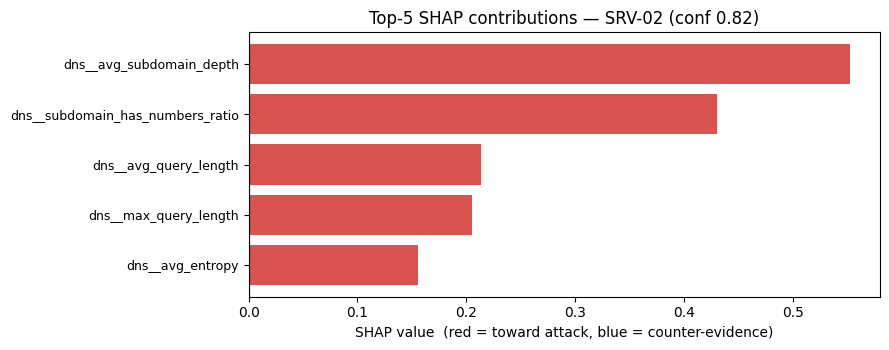

,feature,shap
0,dns__avg_subdomain_depth,0.552231
1,dns__subdomain_has_numbers_ratio,0.430365
2,dns__avg_query_length,0.213292
3,dns__max_query_length,0.205140
4,dns__avg_entropy,0.155113


In [6]:
top = max(detections, key=lambda d: d.confidence)
print(f"Explaining: entity={top.source_entity}  confidence={top.confidence:.3f}  severity={top.severity.name}\n")

# Import matplotlib now — AFTER data-gen/extraction (see Section 0 note).
# The Jupyter kernel auto-selects its inline backend, so figures render in-notebook.
import matplotlib.pyplot as plt

shap = top.contributing_features
sdf = pd.DataFrame({"feature": list(shap.keys()), "shap": list(shap.values())})
sdf = sdf.reindex(sdf["shap"].abs().sort_values().index)   # ascending |shap| for barh

plt.figure(figsize=(9, 3.6))
colors = ["#d9534f" if v > 0 else "#4878cf" for v in sdf["shap"]]
plt.barh(range(len(sdf)), sdf["shap"], color=colors)
plt.yticks(range(len(sdf)), sdf["feature"], fontsize=9)
plt.axvline(0, color="k", lw=.8)
plt.title(f"Top-5 SHAP contributions — {top.source_entity} (conf {top.confidence:.2f})")
plt.xlabel("SHAP value  (red = toward attack, blue = counter-evidence)")
plt.tight_layout(); plt.show()
sdf.iloc[::-1].reset_index(drop=True)

**Reading it.** The drivers are genuine DNS-tunnelling signals (entropy, tunnelling
record-type ratio, beaconing interval CV). This is the payoff of the feature-domain restriction
from Notebook 1 — the explanation is *about DNS*, which is what an analyst can act on.

## 4 · Threshold comparison & severity laddering (Steps 7 & 9)

The detector's operating threshold (default `0.5` in `config/detectors.yml`) trades recall for
false positives. I sweep it and look at **alert volume** and the **severity ladder**
(`>0.8 CRITICAL, >0.6 HIGH, >0.4 MEDIUM, else LOW`) to reason about where to set it.

In [7]:
thresholds = np.round(np.arange(0.3, 0.91, 0.05), 2)
rows = []
pos = labels == 1
for th in thresholds:
    fired = conf >= th
    tp = int((fired & pos).sum()); fp = int((fired & ~pos).sum())
    fn = int((~fired & pos).sum())
    recall = tp / max(1, tp + fn)
    precision = tp / max(1, tp + fp)
    rows.append({"threshold": th, "alerts": int(fired.sum()),
                 "tp": tp, "fp": fp, "recall": round(recall, 3),
                 "precision": round(precision, 3)})
sweep = pd.DataFrame(rows)
sweep

,threshold,alerts,tp,fp,recall,precision
0,0.30,24,15,9,0.625,0.625
1,0.35,18,13,5,0.542,0.722
2,0.40,13,11,2,0.458,0.846
3,0.45,10,9,1,0.375,0.900
4,0.50,7,7,0,0.292,1.000
5,0.55,7,7,0,0.292,1.000
6,0.60,7,7,0,0.292,1.000
7,0.65,6,6,0,0.250,1.000
8,0.70,5,5,0,0.208,1.000
9,0.75,3,3,0,0.125,1.000


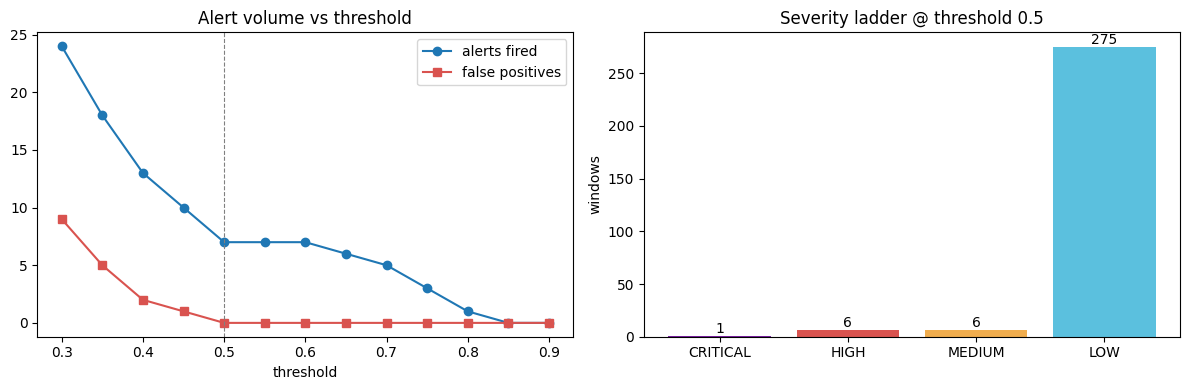

Severity ladder: {'CRITICAL': np.int64(1), 'HIGH': np.int64(6), 'MEDIUM': np.int64(6), 'LOW': np.int64(275)}


In [8]:
# Severity laddering at the default 0.5 operating point
sev = pd.Series([_score_severity(c).name for c in conf]).value_counts()
sev = sev.reindex(["CRITICAL", "HIGH", "MEDIUM", "LOW"]).fillna(0).astype(int)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(sweep["threshold"], sweep["alerts"], marker="o", label="alerts fired")
ax[0].plot(sweep["threshold"], sweep["fp"], marker="s", color="#d9534f", label="false positives")
ax[0].axvline(0.5, ls="--", color="grey", lw=.8)
ax[0].set_xlabel("threshold"); ax[0].set_title("Alert volume vs threshold"); ax[0].legend()

bars = ax[1].bar(sev.index, sev.values,
                 color=["#7b1fa2", "#d9534f", "#f0ad4e", "#5bc0de"])
ax[1].set_title("Severity ladder @ threshold 0.5"); ax[1].set_ylabel("windows")
for b, v in zip(bars, sev.values):
    ax[1].text(b.get_x()+b.get_width()/2, v, str(v), ha="center", va="bottom")
plt.tight_layout(); plt.show()
print("Severity ladder:", dict(sev))

**Tuning note.** On this synthetic stream the scores are well-separated, so 0.5 captures
the attack windows with few false positives. The honest caveat from the training notebook still
stands: on *real* traffic the synthetic-trained model's absolute scores compress, so the
operating threshold would need recalibration from a real-data score distribution rather than
trusting 0.5 blindly.

## 5 · Drift monitoring (Step 9)

Every prediction — above *and* below threshold — is fed to the real
`detection/drift_monitor.py::DriftMonitor`. It auto-initialises a baseline after
`window_size // 2` predictions, then watches three signals: **mean-confidence shift (>0.15)**,
**detection-rate change (>0.10)**, and **PSI on the confidence histogram (≥0.20)**.

I drive it through a clean baseline, confirm **no false alarm**, then inject a distribution
shift (model suddenly scoring much higher — e.g. a campaign or a mis-calibrated promoted model)
and watch it fire.

In [9]:
from detection.drift_monitor import DriftMonitor

def mk_det(score):
    return Detection(
        detection_id="d", detector_name="dns_exfiltration",
        detection_type=DetectionType.DNS_EXFILTRATION, confidence=float(score),
        severity=_score_severity(float(score)), source_entity="SRV-01",
        description="", contributing_features={}, mitre_techniques=[],
        timestamp=__import__("datetime").datetime.now(__import__("datetime").timezone.utc),
        event_window_id="w")

rng = np.random.default_rng(0)
dm = DriftMonitor("dns_exfiltration_demo", window_size=400,
                  persistence_dir=str(ART / "drift"))

# Phase 1 — baseline regime: mostly-benign, low confidences
for _ in range(400):
    dm.record_prediction(mk_det(np.clip(rng.normal(0.15, 0.08), 0, 1)))
dm.set_baseline()
print("baseline mean confidence:", round(dm.baseline_stats["mean_confidence"], 3))

# Same regime again -> should NOT drift
for _ in range(400):
    dm.record_prediction(mk_det(np.clip(rng.normal(0.15, 0.08), 0, 1)))
print("check_drift (same regime):", dm.check_drift())

baseline mean confidence: 0.148
check_drift (same regime): None


In [10]:
# Phase 2 — distribution shift: scores jump up (campaign / mis-calibrated model)
for _ in range(400):
    dm.record_prediction(mk_det(np.clip(rng.normal(0.62, 0.12), 0, 1)))

report = dm.check_drift()
print("check_drift (after shift):")
print(json.dumps(report, indent=2, default=str))
assert report is not None and report["issues"], "expected drift to fire"
print("\nDRIFT DETECTED — signals:", [i["type"] for i in report["issues"]])

MODEL DRIFT DETECTED


check_drift (after shift):
{
  "detector": "dns_exfiltration_demo",
  "timestamp": 1780546598.387725,
  "issues": [
    {
      "type": "confidence_shift",
      "baseline": 0.1442,
      "current": 0.6148,
      "shift": 0.4705
    },
    {
      "type": "detection_rate_change",
      "baseline": 0.0,
      "current": 0.2858,
      "change": -0.2858,
      "direction": "increase (possible false positive spike)"
    },
    {
      "type": "psi_shift",
      "psi": 7.461,
      "scope": "hour-of-day"
    }
  ],
  "recommendation": "Consider retraining with recent data"
}

DRIFT DETECTED — signals: ['confidence_shift', 'detection_rate_change', 'psi_shift']


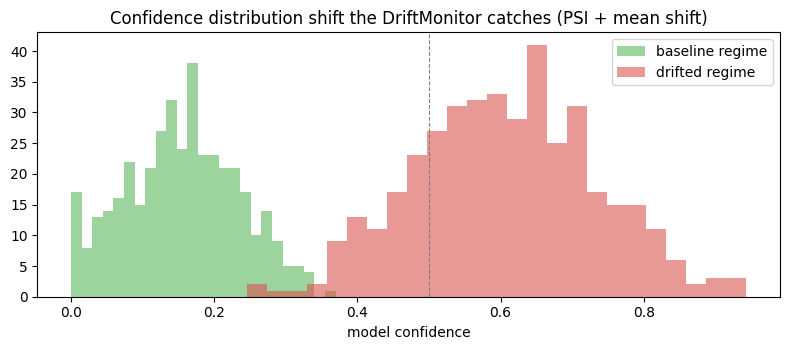

In [11]:
# Visualise the baseline vs drifted confidence distributions
base = np.clip(rng.normal(0.15, 0.08, 400), 0, 1)
drift = np.clip(rng.normal(0.62, 0.12, 400), 0, 1)
plt.figure(figsize=(8, 3.6))
plt.hist(base, bins=25, alpha=.6, label="baseline regime", color="#5cb85c")
plt.hist(drift, bins=25, alpha=.6, label="drifted regime", color="#d9534f")
plt.axvline(0.5, ls="--", color="grey", lw=.8)
plt.title("Confidence distribution shift the DriftMonitor catches (PSI + mean shift)")
plt.xlabel("model confidence"); plt.legend(); plt.tight_layout(); plt.show()

**Why this matters.** In production only a clean→drifting *transition* emits
`MODEL_DRIFT_DETECTED` (debounced to prevent alert storms). A fired drift report is the trigger
for the auto-retrain scheduler / an admin to retrain with recent data — closing the loop back to
Notebook 1's training workflow.

## 6 · Cross-detector check — lateral_movement inference

Quick confirmation the same inference path works for the second detector with its own
`hostname_user` grouping and ~114-feature schema.

In [12]:
windowed_lm = window_events(stream, WINDOW_MINUTES, grouping="hostname_user")
fvs_lm, labels_lm = [], []
for entity, events, label in windowed_lm:
    fvs_lm.append(pipeline.extract_all(events, source_entity=entity))
    labels_lm.append(label)
labels_lm = np.array(labels_lm)

lm_feats = schema['lateral_movement']['feature_names']
dets_lm, conf_lm = predict_batch_demo(
    lm_model, lm_feats, fvs_lm, threshold=0.5,
    detector_name="lateral_movement", detection_type=DetectionType.LATERAL_MOVEMENT)

print(f"lateral windows: {len(dets_lm)}  attack: {int(labels_lm.sum())}  "
      f"fired>=0.5: {int((conf_lm>=0.5).sum())}")
top_lm = max(dets_lm, key=lambda d: d.confidence)
print(f"top lateral detection: {top_lm.source_entity} conf={top_lm.confidence:.3f} "
      f"sev={top_lm.severity.name}")
print("top SHAP features:", list(top_lm.contributing_features.keys()))

lateral windows: 1734  attack: 25  fired>=0.5: 21
top lateral detection: SRV-03:compromised.user conf=0.976 sev=CRITICAL
top SHAP features: ['temporal__events_per_minute', 'auth__network_logon_count', 'temporal__inter_event_interval_mean', 'auth__total_auth_events', 'temporal__burst_factor']


## Summary

| Experiment | Finding |
|---|---|
| Batched inference + schema pin | DNS model selects only its 55 `dns__/temporal__` columns from the full 156-feature window — the per-detector pin holds |
| SHAP (`pred_contribs`) | Top-5 drivers are genuine DNS-tunnelling signals → analyst-actionable explanations |
| Threshold / severity laddering | Swept the operating point; 0.5 separates cleanly on synthetic, but real data needs recalibration |
| DriftMonitor | Real monitor stays quiet on a stable regime and fires (confidence-shift + PSI) on a distribution shift |

Together with Notebook 1 (training/tuning), these two notebooks cover the full backend ML loop:
**train → tune → evaluate → serve → explain → monitor for drift → retrain.**
